In [1]:
import sys, platform, re, unicodedata, html
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB, ComplementNB, BernoulliNB
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, roc_auc_score,
    precision_recall_curve, average_precision_score
)
from sklearn.utils.class_weight import compute_class_weight
from scipy.stats import loguniform, reciprocal
from scipy.sparse import hstack

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Python:", sys.version.split()[0], "| Platform:", platform.platform())

# NLTK data
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

Python: 3.12.7 | Platform: Windows-10-10.0.19045-SP0


True

In [3]:
from pathlib import Path
import pandas as pd

DATA_PATH = Path(r"E:\Sentiment_Analysis_Dataset.csv")  # Raw string avoids escape issues

# Try with Windows-1252 encoding (common for Excel/Windows saved CSVs)
df = pd.read_csv(DATA_PATH, encoding='windows-1252') #encoding='ISO-8859-1'

# Keep only the columns we need
df = df[['text', 'sentiment']].copy()

# Rename sentiment → label
df.rename(columns={"sentiment": "label"}, inplace=True)

assert {'text', 'label'}.issubset(df.columns), "CSV must have 'text' and 'label' columns"

print("Dataset shape:", df.shape)
print(df.head(3))
print(df['label'].value_counts(normalize=True).round(3))


Dataset shape: (27481, 2)
                                             text     label
0             I`d have responded, if I were going   neutral
1   Sooo SAD I will miss you here in San Diego!!!  negative
2                       my boss is bullying me...  negative
label
neutral     0.405
positive    0.312
negative    0.283
Name: proportion, dtype: float64


In [4]:
URL_PATTERN = re.compile(r'https?://\S+|www\.\S+')
USER_PATTERN = re.compile(r'@\w+')
NUM_PATTERN = re.compile(r'\b\d+(\.\d+)?\b')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def normalize_unicode(text: str) -> str:
    return unicodedata.normalize('NFKC', text)

def clean_text_basic(text: str) -> str:
    if not isinstance(text, str):
        return ""
    text = html.unescape(text)
    text = normalize_unicode(text)
    text = URL_PATTERN.sub(' URL ', text)
    text = USER_PATTERN.sub(' USER ', text)
    text = NUM_PATTERN.sub(' NUM ', text)
    text = text.replace('\n', ' ').replace('\r', ' ')
    return text

def tokenize_and_lemmatize(text: str) -> str:
    # light-weight tokenization; avoid heavy stemming which can hurt NB
    tokens = nltk.word_tokenize(text)
    # keep alphanum + placeholders, drop very short tokens
    kept = []
    for t in tokens:
        t = t.lower()
        if t.isalnum() or t in {'url','user','num'}:
            if t not in stop_words:
                kept.append(lemmatizer.lemmatize(t))
    return " ".join(kept)

def preprocess_series(texts: pd.Series) -> pd.Series:
    return texts.fillna("").map(clean_text_basic).map(tokenize_and_lemmatize)

# Apply preprocessing
df['cleaned_text'] = preprocess_series(df['text'])

In [5]:
X = df['cleaned_text'].values
y = df['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print("Train size:", len(X_train), "Test size:", len(X_test))

Train size: 21984 Test size: 5497


In [6]:
word_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.9,
    sublinear_tf=True,
    norm='l2',
    strip_accents='unicode'
)

char_vectorizer = TfidfVectorizer(
    analyzer='char',
    ngram_range=(3, 5),
    min_df=3,
    sublinear_tf=True,
    norm='l2'
)

# We'll fit them inside a Pipeline via FeatureUnion
features = FeatureUnion([
    ('word', word_vectorizer),
    ('char', char_vectorizer)
])

In [7]:
base_nb = ComplementNB(alpha=0.5, norm=True)

pipe = Pipeline([
    ('features', features),
    ('nb', base_nb)
])

# Fit baseline
pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)
y_prob = getattr(pipe, "predict_proba", lambda X: None)(X_test)
print("Baseline Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=3))

Baseline Accuracy: 0.6621793705657631
              precision    recall  f1-score   support

    negative      0.692     0.622     0.655      1556
     neutral      0.626     0.631     0.628      2224
    positive      0.684     0.738     0.710      1717

    accuracy                          0.662      5497
   macro avg      0.667     0.664     0.665      5497
weighted avg      0.663     0.662     0.662      5497



In [8]:
param_distributions = {
    'features__word__ngram_range': [(1,1), (1,2)],
    'features__word__min_df': [2, 3],
    'features__word__max_df': [0.9, 0.95],
    'features__char__ngram_range': [(3,5), (4,5)],
    'features__char__min_df': [3, 5],
    'nb__alpha': loguniform(1e-3, 3) # narrower range
}

# Define cross-validation strategy
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

search = RandomizedSearchCV(
    pipe,
    param_distributions=param_distributions,
    n_iter=10, # fewer iterations
    scoring='f1_macro', # keep macro F1 if labels imbalanced
    n_jobs=-1,
    cv=cv,
    random_state=RANDOM_STATE,
    verbose=1
)

search.fit(X_train, y_train)
print("Best CV score (f1_macro):", search.best_score_)
print("Best params:", search.best_params_)
best_model = search.best_estimator_

y_pred = best_model.predict(X_test)
print("Tuned Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=3))

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best CV score (f1_macro): 0.6494065081886857
Best params: {'features__char__min_df': 3, 'features__char__ngram_range': (3, 5), 'features__word__max_df': 0.95, 'features__word__min_df': 3, 'features__word__ngram_range': (1, 1), 'nb__alpha': 2.2783459357466147}
Tuned Accuracy: 0.6527196652719666
              precision    recall  f1-score   support

    negative      0.750     0.512     0.609      1556
     neutral      0.586     0.727     0.649      2224
    positive      0.701     0.684     0.692      1717

    accuracy                          0.653      5497
   macro avg      0.679     0.641     0.650      5497
weighted avg      0.668     0.653     0.651      5497



In [9]:
cal_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
calibrated = CalibratedClassifierCV(best_model, method='sigmoid', cv=cal_cv)
calibrated.fit(X_train, y_train)

y_pred_cal = calibrated.predict(X_test)
print("Calibrated Accuracy:", accuracy_score(y_test, y_pred_cal))
print(classification_report(y_test, y_pred_cal, digits=3))

# If binary labels 0/1 -> compute ROC-AUC and PR-AUC
is_binary = len(np.unique(y_test)) == 2
if is_binary:
    y_scores = calibrated.predict_proba(X_test)[:, 1]
    roc_auc = roc_auc_score(y_test, y_scores)
    ap = average_precision_score(y_test, y_scores)
    print("ROC-AUC:", round(roc_auc, 4), "| PR-AUC:", round(ap, 4))

Calibrated Accuracy: 0.6610878661087866
              precision    recall  f1-score   support

    negative      0.702     0.593     0.643      1556
     neutral      0.593     0.727     0.653      2224
    positive      0.752     0.638     0.690      1717

    accuracy                          0.661      5497
   macro avg      0.682     0.652     0.662      5497
weighted avg      0.673     0.661     0.662      5497



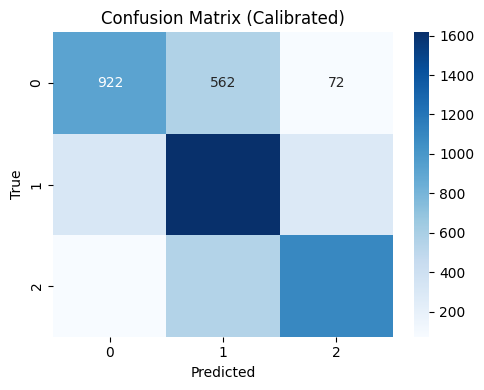

In [10]:
from itertools import product
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_cal)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (Calibrated)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

if is_binary:
    y_scores = calibrated.predict_proba(X_test)[:, 1]
    precision, recall, thresholds = precision_recall_curve(y_test, y_scores)
    plt.figure(figsize=(6,4))
    plt.plot(recall, precision, label='Calibrated NB')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [11]:
def make_nb_pipeline(nb_clf):
    return Pipeline([
        ('features', features),
        ('nb', nb_clf)
    ])

variants = {
    "MultinomialNB": MultinomialNB(alpha=0.5),
    "ComplementNB": ComplementNB(alpha=0.5, norm=True),
    "BernoulliNB": BernoulliNB(alpha=0.5, binarize=0.0)
}

for name, nb in variants.items():
    pl = make_nb_pipeline(nb)
    pl.fit(X_train, y_train)
    yhat = pl.predict(X_test)
    acc = accuracy_score(y_test, yhat)
    print(f"{name:15s} | Accuracy: {acc:.4f}")

MultinomialNB   | Accuracy: 0.6567
ComplementNB    | Accuracy: 0.6622
BernoulliNB     | Accuracy: 0.6562


In [12]:
import joblib
import json

ARTIFACT_DIR = Path("nb_artifacts_2025")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(best_model, ARTIFACT_DIR / "nb_best_model.joblib")
joblib.dump(calibrated, ARTIFACT_DIR / "nb_best_model_calibrated.joblib")

# Persist label mapping if necessary
labels_info = {
    "classes_": getattr(best_model, "classes_", None).tolist() if hasattr(best_model, "classes_") else None
}
(ARTIFACT_DIR / "labels.json").write_text(json.dumps(labels_info, indent=2))

print("Saved artifacts to:", ARTIFACT_DIR.resolve())

Saved artifacts to: C:\Users\DELL\nb_artifacts_2025


In [13]:
from pathlib import Path
import joblib
import pandas as pd
from typing import List, Optional
import numpy as np

def load_model_artifacts(path=Path("nb_artifacts_2025")):
    model = joblib.load(Path(path) / "nb_best_model_calibrated.joblib")
    return model

def predict_texts(texts: List[str], model=None, threshold: Optional[float] = None):
    if model is None:
        model = load_model_artifacts()
    cleaned = preprocess_series(pd.Series(texts))
    if threshold is None:
        if hasattr(model, "predict_proba"):
            probs = model.predict_proba(cleaned)[:, 1]
            print("Debug probs:", np.round(probs, 4))
        preds = model.predict(cleaned)
        return preds
    # thresholding for binary
    probs = model.predict_proba(cleaned)[:, 1]
    return (probs >= threshold).astype(int)

# Demo
demo_texts = [
    "i love this movie",
    "i am feeling sad",
    "I adore Travis at the Hard Rock's new Kelly Cardenas Salon!  I'm always a fan of a great blowout and no stranger to the chains that offer this service; however, Travis has taken the flawless blowout to a whole new level!  Travis's greets you with his perfectly green swoosh in his otherwise perfectly styled black hair and a Vegas-worthy rockstar outfit.  Next comes the most relaxing and incredible shampoo -- where you get a full head message that could cure even the very worst migraine in minutes --- and the scented shampoo room.  Travis has freakishly strong fingers (in a good way) and use the perfect amount of pressure.  That was superb!  Then starts the glorious blowout... where not one, not two, but THREE people were involved in doing the best round-brush action my hair has ever seen.  The team of stylists clearly gets along extremely well, as it's evident from the way they talk to and help one another that it's really genuine and not some corporate requirement.  It was so much fun to be there! Next Travis started with the flat iron.  The way he flipped his wrist to get volume all around without over-doing it and making me look like a Texas pagent girl was admirable.  It's also worth noting that he didn't fry my hair -- something that I've had happen before with less skilled stylists.  At the end of the blowout & style my hair was perfectly bouncey and looked terrific.  The only thing better?  That this awesome blowout lasted for days! Travis, I will see you every single time I'm out in Vegas.  You make me feel beauuuutiful!"
]
print("Demo predictions:", predict_texts(demo_texts))

Debug probs: [0.1417 0.0889 0.4789]
Demo predictions: ['positive' 'negative' 'positive']
